In [1]:
# Build and evaluate an LSTM model for time series prediction Objective:


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

import torch
import torch.nn as nn

In [3]:
# Load dataset
df = pd.read_csv("/content/data (2).csv")

# Use 'open_value' column (assuming 'Close' was intended as a price column)
data = df[['open_value']].values

print(df.head())

    mic symbol          isin        date  open_value  high_value  low_value  \
0  XZAG    CBX  HRZB00ICBEX6  2015-12-30     1689.22     1689.71    1673.62   
1  XZAG    CBX  HRZB00ICBEX6  2015-12-29     1675.79     1691.02    1673.37   
2  XZAG    CBX  HRZB00ICBEX6  2015-12-28     1655.92     1677.17    1652.76   
3  XZAG    CBX  HRZB00ICBEX6  2015-12-23     1647.66     1655.77    1641.41   
4  XZAG    CBX  HRZB00ICBEX6  2015-12-22     1655.71     1655.71    1642.60   

   last_value  change_prev_close_percentage    turnover  
0     1689.63                         -0.02  2017520.82  
1     1689.94                          0.84  1094356.06  
2     1675.88                          1.21  1125687.29  
3     1655.77                          0.49   592284.75  
4     1647.67                         -0.55  2714509.05  


In [4]:
# Scale data between 0 and 1
scaler = MinMaxScaler()

data = scaler.fit_transform(data)

In [5]:
# Function to create sequences
def create_sequences(data, seq_length):

    X = []
    y = []

    for i in range(len(data) - seq_length):

        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])

    return np.array(X), np.array(y)

# Sequence length
seq_length = 10

# Create input-output pairs
X, y = create_sequences(data, seq_length)

print(X.shape)
print(y.shape)

(1488, 10, 1)
(1488, 1)


In [6]:
# 80% training data
train_size = int(len(X) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

In [7]:
# Convert to PyTorch tensors
X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)

y_train = torch.FloatTensor(y_train)
y_test = torch.FloatTensor(y_test)

In [17]:
class LSTMModel(nn.Module):

    def __init__(self):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=1,
            hidden_size=50,
            batch_first=True
        )

        self.fc = nn.Linear(50, 1)

    def forward(self, x):

        out, _ = self.lstm(x)

        out = out[:, -1, :]

        out = self.fc(out)

        return out

# Create model
model = LSTMModel()

# Loss function
criterion = nn.MSELoss()

# Optimizer (reduced learning rate)
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.0001 # Reduced learning rate from 0.001 to 0.0001
)

In [9]:
losses = []

# Train for 50 epochs
for epoch in range(50):

    # Forward pass
    output = model(X_train)

    # Calculate loss
    loss = criterion(output, y_train)

    # Backpropagation
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Save loss
    losses.append(loss.item())

    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

Epoch 1, Loss: nan
Epoch 2, Loss: nan
Epoch 3, Loss: nan
Epoch 4, Loss: nan
Epoch 5, Loss: nan
Epoch 6, Loss: nan
Epoch 7, Loss: nan
Epoch 8, Loss: nan
Epoch 9, Loss: nan
Epoch 10, Loss: nan
Epoch 11, Loss: nan
Epoch 12, Loss: nan
Epoch 13, Loss: nan
Epoch 14, Loss: nan
Epoch 15, Loss: nan
Epoch 16, Loss: nan
Epoch 17, Loss: nan
Epoch 18, Loss: nan
Epoch 19, Loss: nan
Epoch 20, Loss: nan
Epoch 21, Loss: nan
Epoch 22, Loss: nan
Epoch 23, Loss: nan
Epoch 24, Loss: nan
Epoch 25, Loss: nan
Epoch 26, Loss: nan
Epoch 27, Loss: nan
Epoch 28, Loss: nan
Epoch 29, Loss: nan
Epoch 30, Loss: nan
Epoch 31, Loss: nan
Epoch 32, Loss: nan
Epoch 33, Loss: nan
Epoch 34, Loss: nan
Epoch 35, Loss: nan
Epoch 36, Loss: nan
Epoch 37, Loss: nan
Epoch 38, Loss: nan
Epoch 39, Loss: nan
Epoch 40, Loss: nan
Epoch 41, Loss: nan
Epoch 42, Loss: nan
Epoch 43, Loss: nan
Epoch 44, Loss: nan
Epoch 45, Loss: nan
Epoch 46, Loss: nan
Epoch 47, Loss: nan
Epoch 48, Loss: nan
Epoch 49, Loss: nan
Epoch 50, Loss: nan


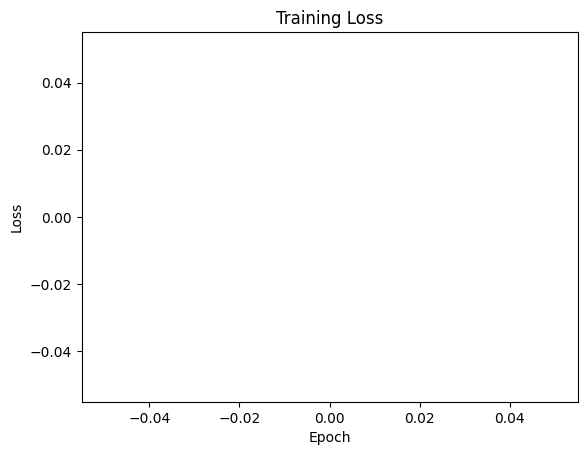

In [10]:
plt.plot(losses)

plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.show()

In [11]:
# Evaluation mode
model.eval()

with torch.no_grad():

    predictions = model(X_test)

# Convert to numpy
predictions = predictions.numpy()
actual = y_test.numpy()

In [18]:
model.eval()

with torch.no_grad():
    predictions = model(X_test)

# Convert to numpy
predictions = predictions.numpy()
actual = y_test.numpy()

# Remove NaN / Inf values safely
predictions = np.nan_to_num(predictions)
actual = np.nan_to_num(actual)

# Reshape for scaler
predictions = predictions.reshape(-1, 1)
actual = actual.reshape(-1, 1)

# Inverse transform
predictions = scaler.inverse_transform(predictions)
actual = scaler.inverse_transform(actual)

In [19]:
# Flatten arrays
predictions = predictions.flatten()
actual = actual.flatten()

# Final safety check (VERY IMPORTANT)
mask = ~np.isnan(actual) & ~np.isnan(predictions)

actual = actual[mask]
predictions = predictions[mask]

# Compute RMSE
rmse = np.sqrt(mean_squared_error(actual, predictions))

print("RMSE:", rmse)

RMSE: 406.62154163915125


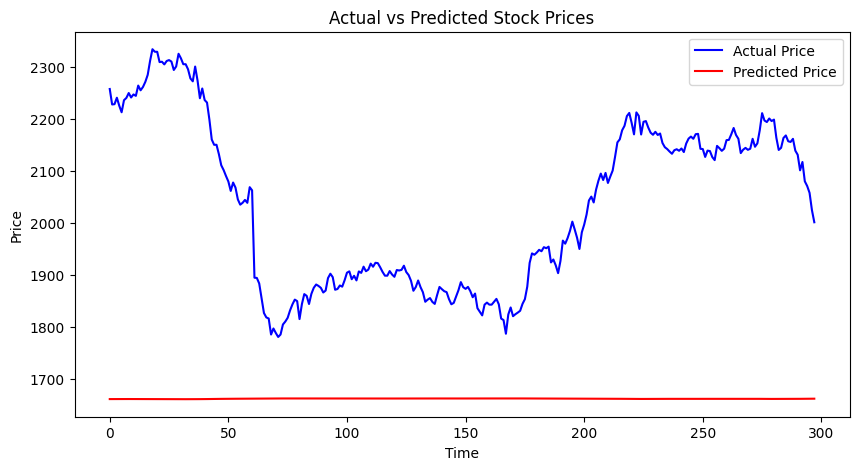

In [20]:
import matplotlib.pyplot as plt

# Plot Actual vs Predicted values
plt.figure(figsize=(10,5))

plt.plot(actual, label="Actual Price", color="blue")
plt.plot(predictions, label="Predicted Price", color="red")

plt.title("Actual vs Predicted Stock Prices")
plt.xlabel("Time")
plt.ylabel("Price")

plt.legend()
plt.show()

In [21]:
#2.(Bonus Task) Build a Text Classification Model using LSTM

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns


In [22]:
# Load dataset (top 5000 words only)
vocab_size = 5000

(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocab_size)

print("Train size:", len(X_train))
print("Test size:", len(X_test))

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Train size: 25000
Test size: 25000


In [23]:
max_len = 200

X_train = pad_sequences(X_train, maxlen=max_len)
X_test = pad_sequences(X_test, maxlen=max_len)

print(X_train.shape)

(25000, 200)


In [24]:
X_train = torch.tensor(X_train, dtype=torch.long)
X_test = torch.tensor(X_test, dtype=torch.long)

y_train = torch.tensor(y_train, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

In [25]:
from torch.utils.data import DataLoader, TensorDataset

batch_size = 64

train_data = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)

In [26]:
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=64, hidden_dim=64):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.embedding(x)
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        out = self.fc(out)
        return self.sigmoid(out)

model = LSTMClassifier(vocab_size)

In [27]:
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [29]:
epochs = 5
loss_list = []

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for x, y in train_loader:
        y = y.view(-1, 1)

        optimizer.zero_grad()
        outputs = model(x)
        loss = criterion(outputs, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    loss_list.append(total_loss / len(train_loader))
    print(f"Epoch {epoch+1}, Loss: {loss_list[-1]:.4f}")

Epoch 1, Loss: 0.6184
Epoch 2, Loss: 0.4983
Epoch 3, Loss: 0.4596
Epoch 4, Loss: 0.3658
Epoch 5, Loss: 0.3091


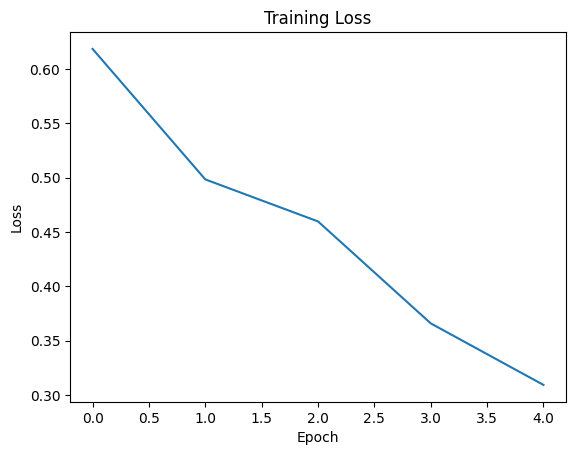

In [30]:
plt.plot(loss_list)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [31]:
model.eval()

with torch.no_grad():
    preds = model(X_test)

preds = preds.numpy()
y_true = y_test.numpy()

y_pred = (preds > 0.5).astype(int)

In [32]:
acc = accuracy_score(y_true, y_pred)
print("Accuracy:", acc)

Accuracy: 0.85352


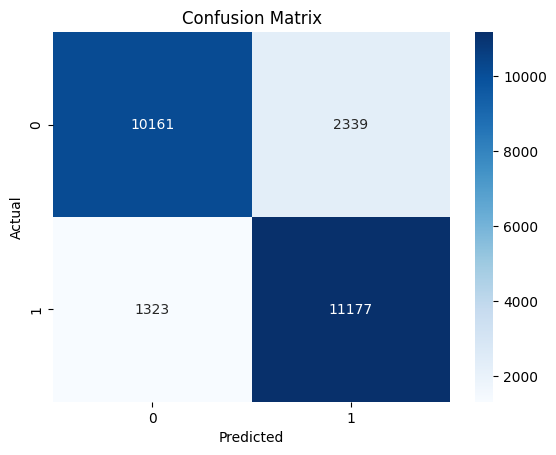

In [33]:
cm = confusion_matrix(y_true, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [34]:
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

         0.0       0.88      0.81      0.85     12500
         1.0       0.83      0.89      0.86     12500

    accuracy                           0.85     25000
   macro avg       0.86      0.85      0.85     25000
weighted avg       0.86      0.85      0.85     25000



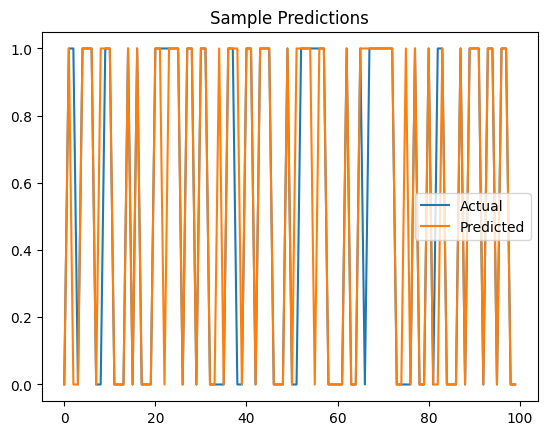

In [35]:
plt.plot(y_true[:100], label="Actual")
plt.plot(y_pred[:100], label="Predicted")
plt.legend()
plt.title("Sample Predictions")
plt.show()